In [ ]:
# Librerias
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import re
import unicodedata
import seaborn as sns
import spacy
from collections import Counter

# Análisis de Sentimientos y Extracción de Información de Comentarios

El **Procesamiento de Lenguaje Natural (NLP)** nos permite:
1. Convertir texto en variables numéricas (features)
2. Detectar patrones semánticos (rechazo, aceptación, llanto, etc.)
3. Crear nuevas variables derivadas que enriquezcan el dataset para análisis posteriores

Se usarán **dos enfoques complementarios**:

| Enfoque | Método | Por qué |  
|---|---|---|
| **Léxico de dominio** | Diccionarios de palabras clave | Máximo control, interpretable, no requiere datos etiquetados |
| **Modelo preentrenado** | `pysentimiento` o `transformers` (BETO) | Captura contexto y negaciones automáticamente |

In [2]:
data = pd.read_csv(r'C:\Users\Maria Paula\OneDrive\Documents\GitHub\Reto_Topo\DataFrameBabyFaceValidacion.csv')
df = pd.DataFrame(data)

# Paso 1. Limpieza de texto

Los modelos de NLP son sensibles a:
- Tildes y mayúsculas (en español especialmente)
- Signos de puntuación extraños
- Notas técnicas mezcladas con observaciones conductuales (ej: "V y A finales de 10.16" no describe comportamiento del bebé)


In [3]:
DATA_CANDIDATES = [
    Path(r"C:\Users\Maria Paula\OneDrive\Documents\GitHub\Reto_Topo\DataFrameBabyFaceValidacion.csv"),
    Path("/mnt/data/DataFrameBabyFaceValidacion.xlsx"),
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró DataFrameBabyFaceValidacion.xlsx. Coloca el Excel en la misma carpeta del notebook.")

OUTPUT_DIR = Path("babyface_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

MISSING_TOKENS = {'', '-', 'NA', 'NA ', 'N/A', 'nan', 'NaN', 'FIT_FAILED', 'FIT FAILED', 'FIND_FAILED', 'S/I', None}

def parse_time_to_seconds(x):
    """Convierte tiempos a segundos. Maneja segundos, milisegundos y formatos tipo HH:MM:SS.mmm."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        value = float(x)
        # Algunos registros están en milisegundos: 16433 -> 16.433 s.
        return value / 1000 if value > 1000 else value
    s = str(x).strip()
    if s in MISSING_TOKENS:
        return np.nan
    if ':' in s:
        try:
            parts = [p.strip() for p in s.split(':')]
            if len(parts) == 3:
                h, m, sec = parts
                return float(h) * 3600 + float(m) * 60 + float(sec)
            if len(parts) == 2:
                m, sec = parts
                return float(m) * 60 + float(sec)
        except Exception:
            pass
    # Casos como 1.00.60 o 1,34,033: se interpretan como minutos, segundos y fracción.
    if re.fullmatch(r'\d+[\.,]\d+[\.,]\d+', s):
        nums = [int(p) for p in re.split(r'[\.,]', s)]
        if len(nums) == 3:
            minutes, seconds, frac = nums
            return minutes * 60 + seconds + frac / (10 ** len(str(frac)))
    try:
        value = float(s.replace(',', '.'))
        return value / 1000 if value > 1000 else value
    except Exception:
        return np.nan

def parse_numeric(x):
    """Convierte a float y manda tokens de error/missing a NaN."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s in MISSING_TOKENS:
        return np.nan
    try:
        return float(s.replace(',', '.'))
    except Exception:
        return np.nan

def parse_day_number(x):
    """Extrae el número de día de etiquetas mixtas como 7E, 7P, 1E 2, 4.2."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in MISSING_TOKENS:
        return np.nan
    match = re.search(r'\d+(?:\.\d+)?', s)
    return float(match.group(0)) if match else np.nan

def parse_phase(x):
    """Extrae si la etiqueta de día tiene E, P, ambas o ninguna."""
    if pd.isna(x):
        return "sin_fase"
    s = str(x).strip().upper()
    if s in MISSING_TOKENS:
        return "sin_fase"
    has_e = 'E' in s
    has_p = 'P' in s
    if has_e and has_p:
        return "E/P"
    if has_e:
        return "E"
    if has_p:
        return "P"
    return "sin_fase"

def load_and_clean(path=DATA_PATH):
    raw = pd.read_csv(path)
    df = raw.copy()

    # Normalización de comentarios y día.
    df['comentarios'] = df['comentarios'].replace({'NA': np.nan, 'NA ': np.nan, '-': np.nan})
    df['dia_original'] = df['dia'].astype(str)
    df['dia_num'] = df['dia'].apply(parse_day_number)
    df['fase_dia'] = df['dia'].apply(parse_phase)

    time_cols = ['t_total', 't_prueba1', 't_prueba2']
    binary_cols = ['rechaza', 'llora', 'toca', 'prueba', 'consume']
    va_cols = [c for c in df.columns if c.startswith('valence') or c.startswith('arousal')]

    for c in time_cols:
        df[c] = df[c].apply(parse_time_to_seconds)
    for c in binary_cols:
        df[c] = df[c].apply(parse_numeric)
    for c in va_cols:
        df[c] = df[c].apply(parse_numeric)

    valence_cols = [c for c in df.columns if c.startswith('valence')]
    arousal_cols = [c for c in df.columns if c.startswith('arousal')]

    # Variables derivadas para EDA y TDA.
    df['valence_mean'] = df[valence_cols].mean(axis=1, skipna=True)
    df['arousal_mean'] = df[arousal_cols].mean(axis=1, skipna=True)
    df['valence_delta'] = df['valence_final'] - df['valence_inicio']
    df['arousal_delta'] = df['arousal_final'] - df['arousal_inicio']
    df['valence_p1_delta'] = df['valence_p1_after'] - df['valence_p1_before']
    df['valence_p2_delta'] = df['valence_p2_after'] - df['valence_p2_before']
    df['arousal_p1_delta'] = df['arousal_p1_after'] - df['arousal_p1_before']
    df['arousal_p2_delta'] = df['arousal_p2_after'] - df['arousal_p2_before']
    df['aceptacion_score'] = df[['prueba','consume']].mean(axis=1, skipna=True) - df[['rechaza','llora']].mean(axis=1, skipna=True)
    df['va_missing_count'] = df[valence_cols + arousal_cols].isna().sum(axis=1)
    return raw, df

raw, df_limpio = load_and_clean()
print(f"Archivo cargado: {DATA_PATH}")
print(f"Dimensiones raw: {raw.shape[0]} filas x {raw.shape[1]} columnas")
print(f"Dimensiones cleaned: {df.shape[0]} filas x {df.shape[1]} columnas")

Archivo cargado: C:\Users\Maria Paula\OneDrive\Documents\GitHub\Reto_Topo\DataFrameBabyFaceValidacion.csv
Dimensiones raw: 366 filas x 27 columnas
Dimensiones cleaned: 366 filas x 27 columnas


In [4]:
print(f"Total de registros: {len(df_limpio)}")
print(f"Comentarios con texto: {df_limpio['comentarios'].notna().sum()}")
print(f"Comentarios vacíos (NA): {df_limpio['comentarios'].isna().sum()}")

Total de registros: 366
Comentarios con texto: 254
Comentarios vacíos (NA): 112


# Paso 2. Creacion de diccionario

In [5]:
# Patrones que indican notas técnicas del analista (no conducta del bebé)
TECHNICAL_PATTERNS = [
    r'[VvAa]\s*y\s*[VvAa]\s*(inicial|final|inicio)',  # "V y A finales de..."
    r'(valence|arousal|valenc)',
    r'datos\s*(de|del|finales|iniciales)',
    r'segundo\s+\d+[\.,]\d+',                          # "segundo 10.16"
    r'\d+[\.,]\d+\s*seg',                               # "10,16 seg"
    r'fit[_\s]failed',
    r'no hay datos',
    r'video (está |fue |inicia )?grabado',
    r'excel',
    r'programa no lo registra',
    r'se usaron los datos',
    r'se tomó (el |los )?dato',
]

def has_technical_note(text):
    """Detecta si el comentario contiene notas técnicas del analista."""
    if pd.isna(text):
        return False
    t = text.lower()
    return any(re.search(p, t) for p in TECHNICAL_PATTERNS)

def clean_text(text):
    """Limpieza básica manteniendo tildes (importantes en español)."""
    if pd.isna(text):
        return np.nan
    # Minúsculas
    t = text.lower().strip()
    # Eliminar caracteres especiales pero mantener ñ, tildes
    t = re.sub(r'[^\w\sáéíóúüñ¿¡,.]', ' ', t)
    # Colapsar espacios
    t = re.sub(r'\s+', ' ', t).strip()
    return t
df = df_limpio.copy()
df['tiene_nota_tecnica'] = df_limpio['comentarios'].apply(has_technical_note)
df['texto_limpio'] = df['comentarios'].apply(clean_text)

print(f"Comentarios con notas técnicas: {df['tiene_nota_tecnica'].sum()}")
print("\nEjemplos de comentarios con notas técnicas detectadas:")
df[df['tiene_nota_tecnica']]['comentarios'].dropna().head(5).tolist()

Comentarios con notas técnicas: 34

Ejemplos de comentarios con notas técnicas detectadas:


['2da vez: 0,49 seg después (0,5 FIT_FAILED)',
 '2da vez: 0,5 antes FIT_FAILED, anotado 0,48. 0,5 después FIT_FAILED, 0,49 anotado',
 'El video está grabado en diagonal a su rostro, por lo que los datos del analisis esta alterados. Come en formato entero',
 'El video está grabado en diagonal a su rostro. Uso de valores mas proximos. ',
 'Bota el pocillo al suelo. No hay datos en excel.']

# 3. Análisis léxico basado en diccionarios de dominio


Un **diccionario de dominio** es un conjunto de palabras clave asociadas a categorías que yo misma defino según el contexto del estudio. Es el método más **transparente, reproducible y controlable**.

**Ventajas:**
- No necesita datos etiquetados
- Se pueden definir exactamente qué palabras activan cada categoría
- Funciona bien con textos cortos y especializados

**Desventaja:**
- No captura negaciones automáticamente ("no rechaza" aún puede activar 'rechazo')
- Requiere mantenimiento manual si aparecen nuevas expresiones

Se construyen categorías alineadas con las variables ya existentes en el dataset.

In [6]:
# ─── Diccionario de dominio

LEXICON = {
    # Conductas de rechazo activo
    'rechazo_activo': [
        'rechaza', 'rechazo', 'rechazando', 'niega', 'negar', 'negando',
        'voltea', 'gira', 'corre la cara', 'correr la cara', 'quita la cara',
        'empuja', 'aleja', 'alejarse', 'escupe', 'devuelve', 'bota',
        'no abre la boca', 'cierra los ojos', 'se tapa', 'tapa la boca',
        'saca la papilla', 'saca la comida', 'saca con las manos',
        'no recibe', 'no consume', 'no lo come', 'no lo prueba'
    ],

    # Llanto y malestar emocional
    'malestar_emocional': [
        'llora', 'llorando', 'llanto', 'pucheros', 'hace pucheros',
        'cara de disgusto', 'disgusto', 'malestar', 'se pone a llorar',
        'casi se pone a llorar', 'pone cara', 'cara de que no le gusta',
        'gestos de que no le gusta', 'con sueño', 'cansado'
    ],

    # Aceptación y consumo
    'aceptacion': [
        'consume', 'come', 'acepta', 'aceptar', 'prueba', 'traga',
        'come con gusto', 'come sola', 'come solo', 'recibe', 'abre la boca',
        'se lo lleva a la boca', 'se lo come', 'mastica', 'muerde',
        'lo acepta', 'tranquilamente'
    ],

    # Exploración (toca, juega, pero no necesariamente come)
    'exploracion': [
        'toca', 'juega', 'jugando', 'agarra', 'toma', 'saborea',
        'se lo lleva a la boca pero no', 'huele', 'mira', 'observa',
        'lo tiene en la mano', 'lo tiene en las manos'
    ],

    # Intervención de terceros (tía, profesora, estudiante)
    'intervencion_adulto': [
        'tía', 'tia', 'profesora', 'estudiante', 'le da', 'le ofrece',
        'dado por', 'dada por', 'ofrecido por', 'en brazos'
    ],

    # Comportamientos autónomos
    'autonomia': [
        'come sola', 'come solo', 'toma sola', 'toma solo', 'él toma',
        'ella toma', 'por su cuenta', 'él come', 'ella come', 'se lo lleva'
    ],

    # Problemas técnicos en los datos
    'problema_datos': [
        'fit_failed', 'fit failed', 'no hay datos', 'no hay registro',
        'no fue leído', 'no fueron leidos', 'sin datos', 'grabado en diagonal',
        'no se grabó', 'no se grabo', 'faltan valores', 'falta'
    ]
}

def match_lexicon(text, word_list):
    """
    Devuelve True si alguna palabra/frase del lexicón aparece en el texto.
    Usamos búsqueda de substrings (no solo palabras completas) para capturar
    variantes morfológicas como 'rechaza' dentro de 'lo rechaza'.
    """
    if pd.isna(text):
        return False
    t = text.lower()
    return any(w in t for w in word_list)

def count_lexicon_matches(text, word_list):
    """Cuenta cuántas palabras del lexicón aparecen (intensidad de la categoría)."""
    if pd.isna(text):
        return 0
    t = text.lower()
    return sum(1 for w in word_list if w in t)

# ─── Crear variables binarias y de conteo ────────────────────────────────────
for category, words in LEXICON.items():
    df[f'lex_{category}'] = df['texto_limpio'].apply(lambda x: int(match_lexicon(x, words)))
    df[f'lex_{category}_score'] = df['texto_limpio'].apply(lambda x: count_lexicon_matches(x, words))

# Variable compuesta: score neto de aceptación vs rechazo
df['lex_net_acceptance'] = df['lex_aceptacion_score'] - df['lex_rechazo_activo_score'] - df['lex_malestar_emocional_score']

print("Variables léxicas creadas:")
lex_cols = [c for c in df.columns if c.startswith('lex_') and '_score' not in c]
print(df[lex_cols].sum().to_string())

Variables léxicas creadas:
lex_rechazo_activo         103
lex_malestar_emocional      22
lex_aceptacion             141
lex_exploracion             87
lex_intervencion_adulto     29
lex_autonomia               19
lex_problema_datos          21
lex_net_acceptance          20


## 4. Manejo de negaciones

### El problema de la negación en análisis léxico

"**No** lo prueba" y "lo prueba" activarían la misma categoría con un diccionario ingenuo. Necesitamos detectar si una palabra clave está precedida de una negación.

La solución clásica es la **ventana de negación**: si dentro de las N palabras anteriores a una palabra clave aparece una negación ('no', 'nunca', 'jamás', 'sin'), invertimos la polaridad.

In [7]:
NEGACIONES = {'no', 'nunca', 'jamás', 'jamas', 'tampoco', 'sin', 'ni'}
VENTANA_NEGACION = 3  # palabras antes de la palabra clave

def tiene_negacion_previa(tokens, idx, ventana=VENTANA_NEGACION):
    """Verifica si hay negación dentro de la ventana anterior al token idx."""
    start = max(0, idx - ventana)
    return any(t in NEGACIONES for t in tokens[start:idx])

def analizar_con_negacion(text, pos_words, neg_words=None):
    """
    Analiza un texto considerando negaciones.
    pos_words: palabras de aceptación.
    neg_words: palabras de rechazo.
    Retorna: score neto (+1 por aceptación, -1 por rechazo o aceptación negada)
    """
    if pd.isna(text):
        return 0
    tokens = text.lower().split()
    score = 0
    for i, token in enumerate(tokens):
        # Limpiar puntuación del token
        tok = re.sub(r'[^\wáéíóúüñ]', '', token)
        negado = tiene_negacion_previa(tokens, i)

        if any(pw in tok for pw in pos_words):
            score += -1 if negado else +1
        if neg_words and any(nw in tok for nw in neg_words):
            score += +1 if negado else -1  # negación de rechazo = señal positiva
    return score

PALABRAS_ACEPTACION = ['consume', 'come', 'acepta', 'prueba', 'traga', 'recibe', 'abre']
PALABRAS_RECHAZO = ['rechaza', 'niega', 'voltea', 'empuja', 'aleja', 'escupe', 'devuelve']

df['score_negacion'] = df['texto_limpio'].apply(
    lambda x: analizar_con_negacion(x, PALABRAS_ACEPTACION, PALABRAS_RECHAZO)
)

print("Distribución del score con negaciones:")
print(df['score_negacion'].value_counts().sort_index())

Distribución del score con negaciones:
score_negacion
-3      1
-2     15
-1     63
 0    198
 1     70
 2     18
 3      1
Name: count, dtype: int64


## 5. Análisis de sentimiento con modelo preentrenado

### ¿Por qué usar un modelo preentrenado además del léxico?

`pysentimiento` usa **RoBERTuito**, un modelo tipo Transformer entrenado en millones de textos en español. A diferencia del léxico:
- Entiende el **contexto** de la oración completa
- Maneja negaciones y modificadores automáticamente
- Captura expresiones idiomáticas

**Limitación importante:** fue entrenado principalmente en Twitter. Para texto clínico/conductual como este, puede tener sesgos. Por eso lo usamos como señal complementaria, no como fuente única.

Las etiquetas del modelo son: `POS` (positivo), `NEG` (negativo), `NEU` (neutro)

In [8]:
try:
    from pysentimiento import create_analyzer
    analyzer = create_analyzer(task="sentiment", lang="es")
    PYSENTIMIENTO_DISPONIBLE = True
    print("pysentimiento cargado correctamente.")
except ImportError:
    PYSENTIMIENTO_DISPONIBLE = False
    print("pysentimiento no disponible. Instálalo con: pip install pysentimiento")
    print("Se usará solo el análisis léxico.")

def get_sentiment_pysentimiento(text):
    """
    Retorna dict con etiqueta de sentimiento y probabilidades.
    Solo analiza comentarios conductuales (no puramente técnicos).
    """
    if pd.isna(text) or not PYSENTIMIENTO_DISPONIBLE:
        return {'label': np.nan, 'POS': np.nan, 'NEG': np.nan, 'NEU': np.nan}
    # Limitar longitud (el modelo tiene un límite de tokens)
    text_truncated = text[:512]
    try:
        result = analyzer.predict(text_truncated)
        probs = result.probas
        return {
            'label': result.output,
            'POS': probs.get('POS', np.nan),
            'NEG': probs.get('NEG', np.nan),
            'NEU': probs.get('NEU', np.nan)
        }
    except Exception as e:
        return {'label': np.nan, 'POS': np.nan, 'NEG': np.nan, 'NEU': np.nan}

if PYSENTIMIENTO_DISPONIBLE:
    print("Analizando sentimientos... (puede tardar 1-2 minutos)")
    resultados = df['texto_limpio'].apply(get_sentiment_pysentimiento)
    df['sentiment_label'] = resultados.apply(lambda x: x['label'])
    df['sentiment_pos'] = resultados.apply(lambda x: x['POS'])
    df['sentiment_neg'] = resultados.apply(lambda x: x['NEG'])
    df['sentiment_neu'] = resultados.apply(lambda x: x['NEU'])
    # Score continuo: diferencia POS - NEG (rango -1 a +1)
    df['sentiment_score'] = df['sentiment_pos'] - df['sentiment_neg']
    print("\nDistribución de etiquetas de sentimiento:")
    print(df['sentiment_label'].value_counts())
else:
    # Rellenar con NaN para que el pipeline no falle
    for col in ['sentiment_label', 'sentiment_pos', 'sentiment_neg', 'sentiment_neu', 'sentiment_score']:
        df[col] = np.nan
    print("Variables de sentimiento creadas como NaN (modelo no disponible).")

pysentimiento no disponible. Instálalo con: pip install pysentimiento
Se usará solo el análisis léxico.
Variables de sentimiento creadas como NaN (modelo no disponible).


## 6. Extracción de información estructurada adicional

### Variables de comportamiento observacional

Más allá del sentimiento general, podemos extraer variables **específicas del dominio** que tienen hipótesis claras en el estudio (ej: ¿el bebé fue autónomo?, ¿hubo intervención?).

In [9]:
def extraer_features_conductuales(text):
    """
    Extrae variables conductuales específicas del dominio a partir de reglas.
    Retorna un diccionario con variables binarias.
    """
    if pd.isna(text):
        return {k: np.nan for k in [
            'cond_gira_cara', 'cond_usa_manos', 'cond_llora_malestar',
            'cond_juega_alimento', 'cond_autonomo', 'cond_adulto_interviene',
            'cond_formato_entero', 'cond_formato_papilla', 'cond_video_problema',
            'cond_segunda_prueba', 'cond_ambivalente'
        ]}
    t = text.lower()

    # Detecta si el rechazo fue girando la cara (señal corporal específica)
    gira_cara = bool(re.search(r'gir[ao] (la |el )?(cara|rostro|cabeza)|voltea (la |el )?(cara|rostro)', t))

    # Usa las manos para rechazar o explorar
    usa_manos = bool(re.search(r'(con|en) las manos|manos a la (cara|cabeza)|con las manos|empuja .{0,15} mano', t))

    # Llanto o señales de malestar
    llora = bool(re.search(r'llor[ao]|pucheros|casi se pone a llorar', t))

    # Juega con el alimento (exploración lúdica, no necesariamente consumo)
    juega = bool(re.search(r'jueg[ao] con (el|la|un|los) alimento|jueg[ao] con (el |la )?pocillo|jueg[ao] con (el |la )?cuchara', t))

    # Conducta autónoma (come o toma por sí mismo)
    autonomo = bool(re.search(r'(come|toma|prueba) sol[ao]|él (come|toma|prueba)|ella (come|toma)|por su cuenta|él toma|lo toma (él|solo)', t))

    # Adulto interviene (no espontáneo)
    adulto = bool(re.search(r'(tía|tia|profesora|estudiante) (le da|le ofrece|lo pone|lo da|ofrece)|dado por|dada por|en brazos', t))

    # Formato de presentación del alimento
    entero = bool(re.search(r'entero|trozo|pedacito|formato (e|entero)', t))
    papilla = bool(re.search(r'papilla|cucharad[ao]|cuchara', t))

    # Problemas técnicos del video o datos
    video_problema = bool(re.search(r'no hay datos|diagonal|fit.?failed|no se grab|no fue leíd|sin datos|no fueron leidos|no hay registro', t))

    # Menciona segunda prueba explícitamente
    segunda = bool(re.search(r'segunda (vez|prueba)|2da|2a vez', t))

    # Ambivalencia (primero rechaza, luego acepta o viceversa)
    ambivalente = bool(re.search(
        r'(al principio|primero|inicio|primer[ao]).{0,40}(pero|luego|después|despues|finalmente).{0,40}(acepta|consume|prueba|come)|'
        r'(acepta|consume|prueba|come).{0,40}(pero|luego|después|despues).{0,40}(rechaza|niega|no)', t
    ))

    return {
        'cond_gira_cara': int(gira_cara),
        'cond_usa_manos': int(usa_manos),
        'cond_llora_malestar': int(llora),
        'cond_juega_alimento': int(juega),
        'cond_autonomo': int(autonomo),
        'cond_adulto_interviene': int(adulto),
        'cond_formato_entero': int(entero),
        'cond_formato_papilla': int(papilla),
        'cond_video_problema': int(video_problema),
        'cond_segunda_prueba': int(segunda),
        'cond_ambivalente': int(ambivalente)
    }

# Aplicar y expandir en columnas
features_conductuales = df['texto_limpio'].apply(extraer_features_conductuales)
df_cond = pd.DataFrame(features_conductuales.tolist())
df = pd.concat([df.reset_index(drop=True), df_cond], axis=1)

print("Variables conductuales extraídas:")
cond_cols = [c for c in df.columns if c.startswith('cond_')]
print(df[cond_cols].sum().to_string())

Variables conductuales extraídas:
cond_gira_cara             4.0
cond_usa_manos             8.0
cond_llora_malestar       13.0
cond_juega_alimento        8.0
cond_autonomo             15.0
cond_adulto_interviene    11.0
cond_formato_entero       14.0
cond_formato_papilla      63.0
cond_video_problema       21.0
cond_segunda_prueba       17.0
cond_ambivalente          11.0


## 7. Visualizaciones exploratorias

### ¿Por qué visualizar antes de modelar?

Las visualizaciones nos permiten:
1. Detectar si las variables extraídas tienen sentido semántico
2. Identificar correlaciones entre variables textuales y variables de respuesta
3. Comunicar hallazgos de forma intuitiva

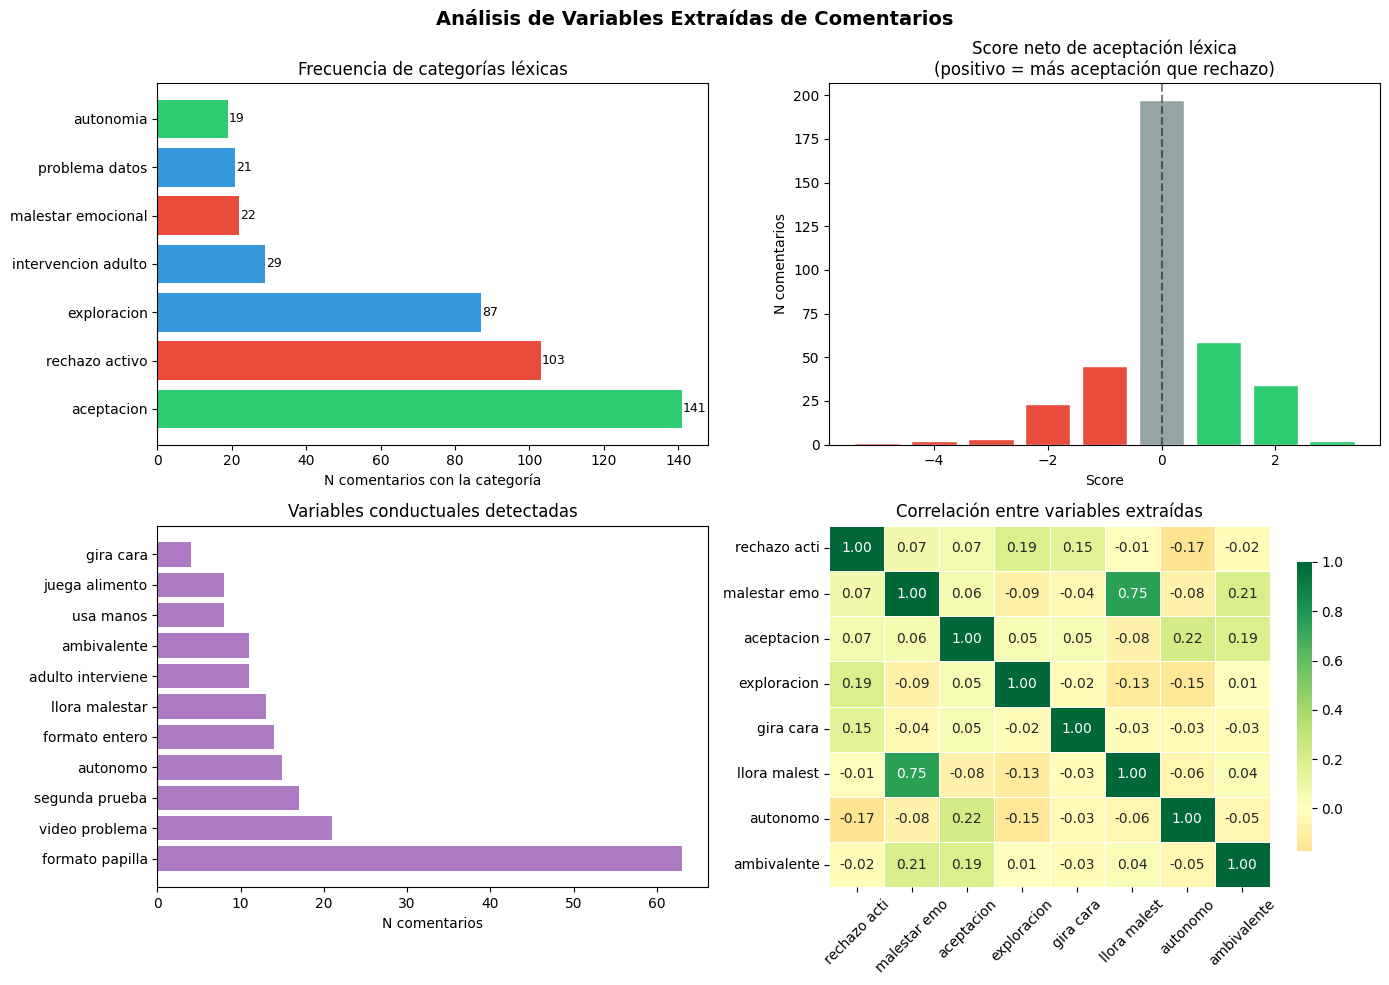

Gráfico guardado como 'babyface_nlp_overview.png'


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis de Variables Extraídas de Comentarios', fontsize=14, fontweight='bold')

# ── Plot 1: Frecuencia de categorías léxicas ─────────────────────────────────
ax = axes[0, 0]
lex_binary = {c.replace('lex_', '').replace('_', ' '): df[c].sum()
              for c in df.columns if c.startswith('lex_') and '_score' not in c and 'net' not in c}
lex_binary = dict(sorted(lex_binary.items(), key=lambda x: x[1], reverse=True))
colors = ['#e74c3c' if 'rechazo' in k or 'malestar' in k else
          '#2ecc71' if 'aceptacion' in k or 'autono' in k else
          '#3498db' for k in lex_binary.keys()]
bars = ax.barh(list(lex_binary.keys()), list(lex_binary.values()), color=colors)
ax.set_title('Frecuencia de categorías léxicas')
ax.set_xlabel('N comentarios con la categoría')
for bar, val in zip(bars, lex_binary.values()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=9)

# ── Plot 2: Distribución del score neto de aceptación ────────────────────────
ax = axes[0, 1]
score_counts = df['lex_net_acceptance'].value_counts().sort_index()
colors_score = ['#e74c3c' if x < 0 else '#95a5a6' if x == 0 else '#2ecc71'
                for x in score_counts.index]
ax.bar(score_counts.index, score_counts.values, color=colors_score, edgecolor='white')
ax.set_title('Score neto de aceptación léxica\n(positivo = más aceptación que rechazo)')
ax.set_xlabel('Score')
ax.set_ylabel('N comentarios')
ax.axvline(0, color='black', linestyle='--', alpha=0.5)

# ── Plot 3: Distribución de variables conductuales ────────────────────────────
ax = axes[1, 0]
cond_counts = {c.replace('cond_', '').replace('_', ' '): df[c].sum()
               for c in df.columns if c.startswith('cond_') and df[c].sum() > 0}
cond_counts = dict(sorted(cond_counts.items(), key=lambda x: x[1], reverse=True))
ax.barh(list(cond_counts.keys()), list(cond_counts.values()),
        color='#9b59b6', alpha=0.8)
ax.set_title('Variables conductuales detectadas')
ax.set_xlabel('N comentarios')

# ── Plot 4: Heatmap de correlación entre variables extraídas ──────────────────
ax = axes[1, 1]
cols_corr = ['lex_rechazo_activo', 'lex_malestar_emocional', 'lex_aceptacion',
             'lex_exploracion', 'cond_gira_cara', 'cond_llora_malestar',
             'cond_autonomo', 'cond_ambivalente']
cols_corr = [c for c in cols_corr if c in df.columns]
if len(cols_corr) >= 2:
    corr_matrix = df[cols_corr].corr()
    labels_short = [c.replace('lex_', '').replace('cond_', '').replace('_', ' ')[:12]
                    for c in cols_corr]
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, ax=ax, xticklabels=labels_short, yticklabels=labels_short,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title('Correlación entre variables extraídas')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('babyface_nlp_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como 'babyface_nlp_overview.png'")

**Validación cruzada**

In [11]:
# ─── Validación cruzada: ¿Las variables de texto coinciden con las binarias del dataset? ─
# Esta celda solo funciona si tienes las columnas 'rechaza', 'llora', 'prueba', 'consume'

validacion_cols = {
    'lex_rechazo_activo': 'rechaza',
    'lex_malestar_emocional': 'llora',
    'lex_aceptacion': 'prueba'
}

print("=" * 60)
print("VALIDACIÓN CRUZADA: texto vs. variables estructuradas")
print("=" * 60)
print("¿Cuándo el texto dice 'rechazo' pero la variable rechaza=0?")
print("Esto puede indicar inconsistencias en la codificación manual.\n")

for lex_col, struct_col in validacion_cols.items():
    if struct_col in df.columns:
        coincide = ((df[lex_col] == 1) & (df[struct_col] == 1)).sum()
        discrepa_tex_si = ((df[lex_col] == 1) & (df[struct_col] == 0)).sum()
        discrepa_tex_no = ((df[lex_col] == 0) & (df[struct_col] == 1)).sum()
        total_tex = df[lex_col].sum()
        print(f"  {lex_col} vs {struct_col}:")
        print(f"    Ambos = 1 (coinciden):          {coincide}")
        print(f"    Texto=1 pero variable=0 (nuevo): {discrepa_tex_si}")
        print(f"    Texto=0 pero variable=1 (perdido): {discrepa_tex_no}")
        print()

VALIDACIÓN CRUZADA: texto vs. variables estructuradas
¿Cuándo el texto dice 'rechazo' pero la variable rechaza=0?
Esto puede indicar inconsistencias en la codificación manual.

  lex_rechazo_activo vs rechaza:
    Ambos = 1 (coinciden):          91
    Texto=1 pero variable=0 (nuevo): 12
    Texto=0 pero variable=1 (perdido): 70

  lex_malestar_emocional vs llora:
    Ambos = 1 (coinciden):          7
    Texto=1 pero variable=0 (nuevo): 13
    Texto=0 pero variable=1 (perdido): 13

  lex_aceptacion vs prueba:
    Ambos = 1 (coinciden):          113
    Texto=1 pero variable=0 (nuevo): 27
    Texto=0 pero variable=1 (perdido): 134



## 8. Word Cloud y análisis de frecuencias

Antes de construir el léxico (o para refinarlo), es útil ver qué palabras aparecen más en comentarios de cada tipo. Esto permite:
- Descubrir términos que omitiste en el diccionario
- Confirmar que el léxico captura las palabras más frecuentes
- Detectar jerga específica del equipo investigador

In [12]:
try:
    import es_core_news_sm
    nlp = es_core_news_sm.load()
    SPACY_DISPONIBLE = True
    print("spaCy cargado correctamente:", nlp.meta['name'])
except Exception as e:
    print("Error:", e)
    SPACY_DISPONIBLE = False

# Stop words en español (palabras vacías que no aportan significado)
STOP_WORDS_EXTRA = {
    'el', 'la', 'los', 'las', 'de', 'del', 'en', 'a', 'al', 'y', 'que',
    'le', 'se', 'lo', 'su', 'un', 'una', 'con', 'por', 'para', 'pero',
    'más', 'mas', 'o', 'no', 'sí', 'si', 'ya', 'ni', 'todo', 'toda',
    'cuando', 'vez', 'veces', 'primer', 'primera', 'segunda', 'solo', 'sola'
}

def tokenizar(text):
    """Extrae lemas (forma base) de las palabras usando spaCy, excluyendo stop words."""
    if pd.isna(text) or not SPACY_DISPONIBLE:
        return []
    doc = nlp(text[:500])  # límite de velocidad
    tokens = [
        token.lemma_.lower() for token in doc
        if not token.is_stop
        and not token.is_punct
        and token.lemma_.lower() not in STOP_WORDS_EXTRA
        and len(token.lemma_) > 2
    ]
    return tokens

if SPACY_DISPONIBLE:
    # Frecuencias globales
    todos_tokens = []
    for t in df['texto_limpio'].dropna():
        todos_tokens.extend(tokenizar(t))

    freq_global = Counter(todos_tokens)

    print("TOP 30 palabras más frecuentes en comentarios:")
    top30 = freq_global.most_common(30)
    print(pd.DataFrame(top30, columns=['palabra', 'frecuencia']).to_string(index=False))

    # Frecuencias por grupo: rechazo vs aceptación
    tokens_rechazo = []
    tokens_aceptacion = []
    for _, row in df[df['texto_limpio'].notna()].iterrows():
        toks = tokenizar(row['texto_limpio'])
        if row.get('lex_rechazo_activo', 0) == 1:
            tokens_rechazo.extend(toks)
        elif row.get('lex_aceptacion', 0) == 1:
            tokens_aceptacion.extend(toks)

    print("\nTOP 15 palabras en comentarios de RECHAZO:")
    print(pd.DataFrame(Counter(tokens_rechazo).most_common(15), columns=['palabra', 'freq']).to_string(index=False))

    print("\nTOP 15 palabras en comentarios de ACEPTACIÓN:")
    print(pd.DataFrame(Counter(tokens_aceptacion).most_common(15), columns=['palabra', 'freq']).to_string(index=False))

spaCy cargado correctamente: core_news_sm
TOP 30 palabras más frecuentes en comentarios:
  palabra  frecuencia
    video          56
   probar          51
 alimento          49
 coliflor          45
    tocar          42
     mano          40
  papilla          38
     boca          38
   prueba          36
  pocillo          35
     come          26
  iniciar          26
 rechazar          25
cucharada          23
 consumir          22
     dato          22
     cara          20
 devolver          20
  cuchara          19
    jugar          19
    tomar          18
   cabeza          16
    comar          15
    negar          14
      tía          13
  empujar          11
      2da          10
      0.5           9
    labio           9
  recibir           9

TOP 15 palabras en comentarios de RECHAZO:
  palabra  freq
   probar    28
  pocillo    27
 rechazar    25
    tocar    24
  papilla    21
 alimento    21
 devolver    19
     cara    18
     mano    17
cucharada    16
   cabeza

# Dataset Final


In [13]:
# ─── Columnas finales de NLP ─────────────────────────────────────────────────
nlp_cols = (
    ['comentarios', 'texto_limpio', 'tiene_nota_tecnica'] +
    [c for c in df.columns if c.startswith('lex_')] +
    [c for c in df.columns if c.startswith('cond_')] +
    ['score_negacion'] +
    ([c for c in ['sentiment_label', 'sentiment_pos', 'sentiment_neg', 'sentiment_neu', 'sentiment_score']
      if c in df.columns])
)

df_nlp = df[nlp_cols].copy()

# ─── Clasificación conductual resumida ───────────────────────────────────────
def clasificar_conducta(row):
    """
    Asigna una etiqueta resumen de la conducta basada en las variables extraídas.
    Jerarquía: llanto > rechazo_activo > ambivalente > aceptacion > exploracion > sin_info
    """
    if pd.isna(row['texto_limpio']):
        return 'sin_comentario'
    if row.get('cond_llora_malestar', 0) == 1:
        return 'rechazo_con_llanto'
    if row.get('lex_rechazo_activo', 0) == 1 and row.get('lex_aceptacion', 0) == 0:
        return 'rechazo_puro'
    if row.get('cond_ambivalente', 0) == 1:
        return 'ambivalente'
    if row.get('lex_aceptacion', 0) == 1 and row.get('lex_rechazo_activo', 0) == 0:
        return 'aceptacion_pura'
    if row.get('lex_aceptacion', 0) == 1 and row.get('lex_rechazo_activo', 0) == 1:
        return 'aceptacion_con_resistencia'
    if row.get('lex_exploracion', 0) == 1:
        return 'solo_explora'
    if row.get('tiene_nota_tecnica', False):
        return 'nota_tecnica'
    return 'sin_clasificar'

df_nlp['conducta_resumen'] = df.apply(clasificar_conducta, axis=1)

print("Distribución de la clasificación conductual:")
print(df_nlp['conducta_resumen'].value_counts().to_string())
print(f"\nTotal de variables NLP generadas: {len(nlp_cols)}")
print("\nPrimeras 5 filas del dataset NLP:")
df_nlp[['comentarios', 'conducta_resumen', 'lex_net_acceptance', 'cond_autonomo']].head()

Distribución de la clasificación conductual:
conducta_resumen
sin_comentario                112
aceptacion_pura                86
rechazo_puro                   54
aceptacion_con_resistencia     40
solo_explora                   27
rechazo_con_llanto             13
nota_tecnica                   13
sin_clasificar                 11
ambivalente                    10

Total de variables NLP generadas: 35

Primeras 5 filas del dataset NLP:


,comentarios,conducta_resumen,lex_net_acceptance,cond_autonomo
0,NaN,sin_comentario,0,NaN
1,NaN,sin_comentario,0,NaN
2,NaN,sin_comentario,0,NaN
3,"Sólo lo consume la 1ra vez, 2da sólo pruba",aceptacion_pura,1,0.0
4,NaN,sin_comentario,0,NaN


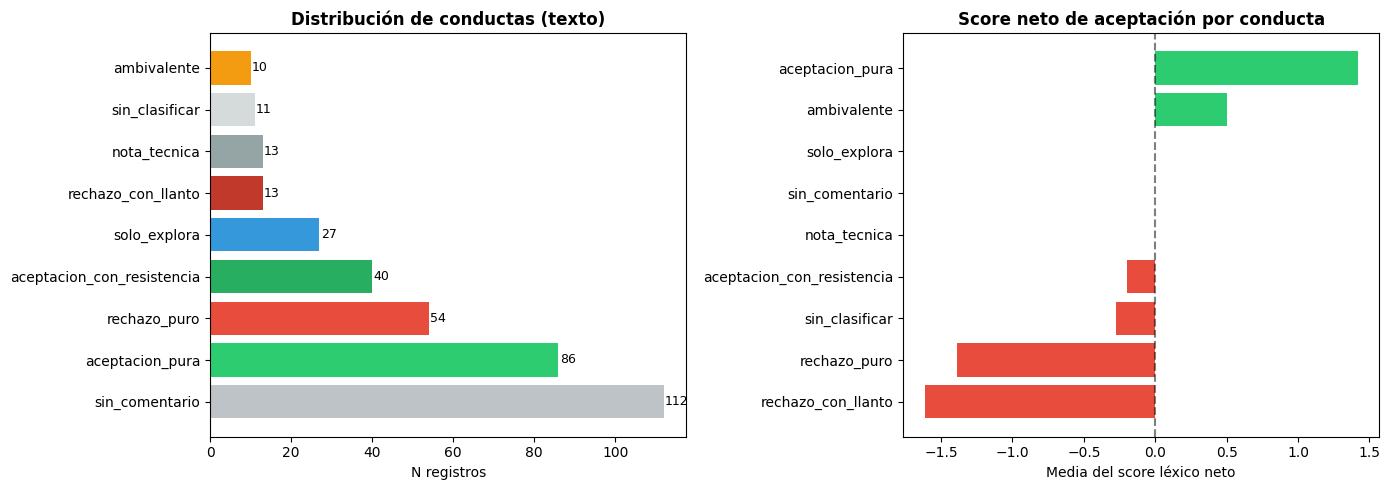

In [14]:
# ─── Visualización: distribución de conductas ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de clases
ax = axes[0]
conducta_counts = df_nlp['conducta_resumen'].value_counts()
color_map = {
    'rechazo_con_llanto': '#c0392b',
    'rechazo_puro': '#e74c3c',
    'ambivalente': '#f39c12',
    'aceptacion_con_resistencia': '#27ae60',
    'aceptacion_pura': '#2ecc71',
    'solo_explora': '#3498db',
    'nota_tecnica': '#95a5a6',
    'sin_comentario': '#bdc3c7',
    'sin_clasificar': '#d5dbdb'
}
colors_plot = [color_map.get(k, '#999999') for k in conducta_counts.index]
bars = ax.barh(conducta_counts.index, conducta_counts.values, color=colors_plot)
ax.set_title('Distribución de conductas (texto)', fontsize=12, fontweight='bold')
ax.set_xlabel('N registros')
for bar, val in zip(bars, conducta_counts.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=9)

# Score neto por categoría
ax = axes[1]
score_by_conducta = df_nlp.groupby('conducta_resumen')['lex_net_acceptance'].mean().sort_values()
colors_score = ['#e74c3c' if v < 0 else '#2ecc71' for v in score_by_conducta.values]
ax.barh(score_by_conducta.index, score_by_conducta.values, color=colors_score)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set_title('Score neto de aceptación por conducta', fontsize=12, fontweight='bold')
ax.set_xlabel('Media del score léxico neto')

plt.tight_layout()
plt.savefig('babyface_conductas.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
df.to_csv('babyface_dataset_nlp.csv', index=False)